## **Early Prediction of Obesity-Related Cardiovascular Risk Using Machine Learning Models**

Dataset Link: https://www.kaggle.com/datasets/noeyislearning/framingham-heart-study

#### **Dataset Download**

In [40]:
!pip install -q kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d noeyislearning/framingham-heart-study

!unzip framingham-heart-study.zip

Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/noeyislearning/framingham-heart-study
License(s): CC0-1.0
framingham-heart-study.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  framingham-heart-study.zip
replace framingham_heart_study.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: framingham_heart_study.csv  


In [41]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

#### **Loading Dataset**

In [42]:
data = pd.read_csv('/content/framingham_heart_study.csv')
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


#### **Exploratory Data Analysis**

In [43]:
df = data.copy()

df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


**Unique value count in each column**

In [44]:
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

Dataset has 4240 rows and 16 columns


In [45]:
# Renaming column names

df.rename(columns={"male": "gender"}, inplace=True)
df.columns

Index(['gender', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

**Gender column data mapping**

In [46]:
binary_cols = ['currentSmoker','diabetes',
               'prevalentHyp','prevalentStroke',
               'TenYearCHD','BPMeds']

for col in binary_cols:
    df[col] = df[col].map({0:"No", 1:"Yes"})

In [47]:
df['gender'] = df['gender'].map({0: "female", 1: "male"})

In [48]:
df.head()

,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,male,39,4.0,No,0.0,No,No,No,No,195.0,106.0,70.0,26.97,80.0,77.0,No
1,female,46,2.0,No,0.0,No,No,No,No,250.0,121.0,81.0,28.73,95.0,76.0,No
2,male,48,1.0,Yes,20.0,No,No,No,No,245.0,127.5,80.0,25.34,75.0,70.0,No
3,female,61,3.0,Yes,30.0,No,No,Yes,No,225.0,150.0,95.0,28.58,65.0,103.0,Yes
4,female,46,3.0,Yes,23.0,No,No,No,No,285.0,130.0,84.0,23.10,85.0,85.0,No


**Gender distribution for TenYearCHD**

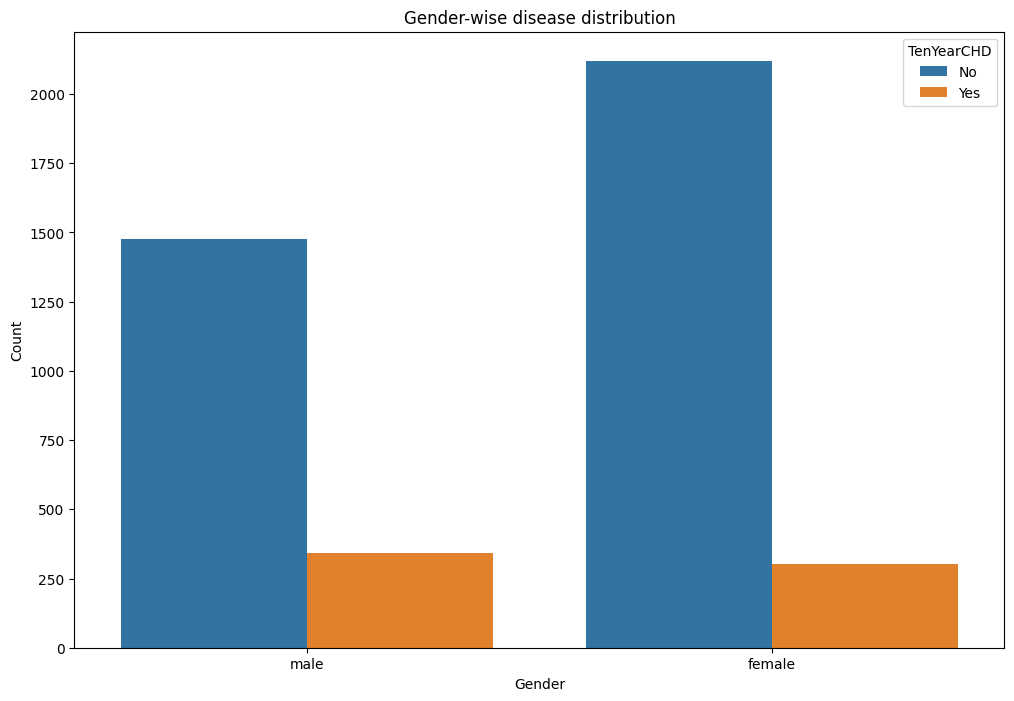

In [49]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, x='gender', hue='TenYearCHD')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.title("Gender-wise disease distribution")
plt.show()

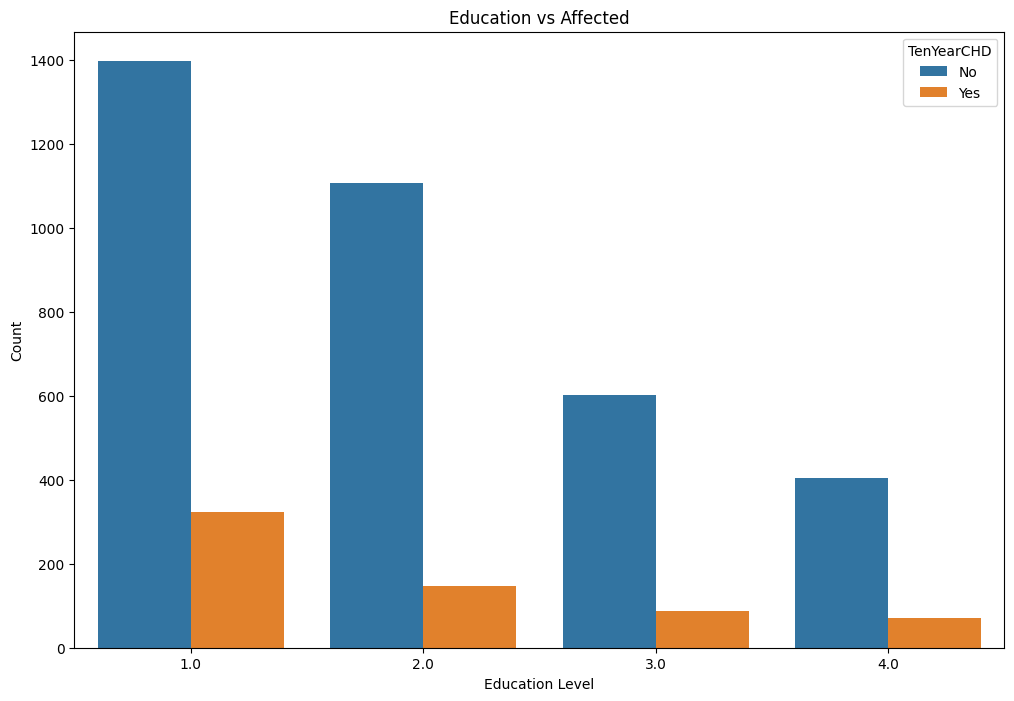

In [50]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='education', hue='TenYearCHD')
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.title("Education vs Affected")
plt.show()

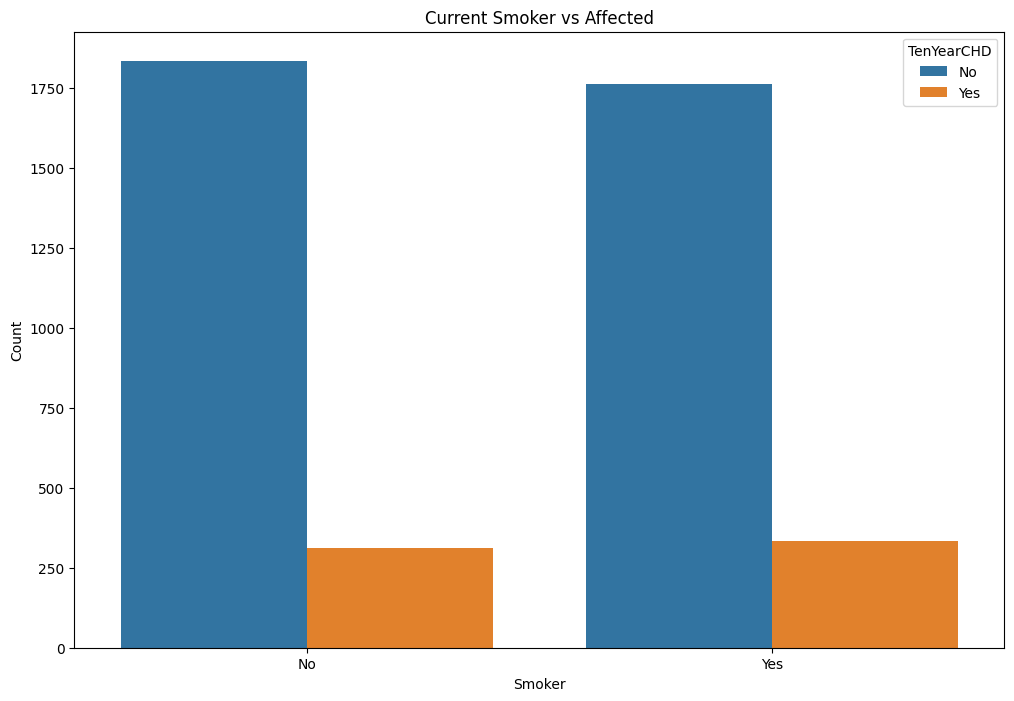

In [51]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='currentSmoker', hue='TenYearCHD')
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.title("Current Smoker vs Affected")
plt.show()

**Has Blood Pressure**

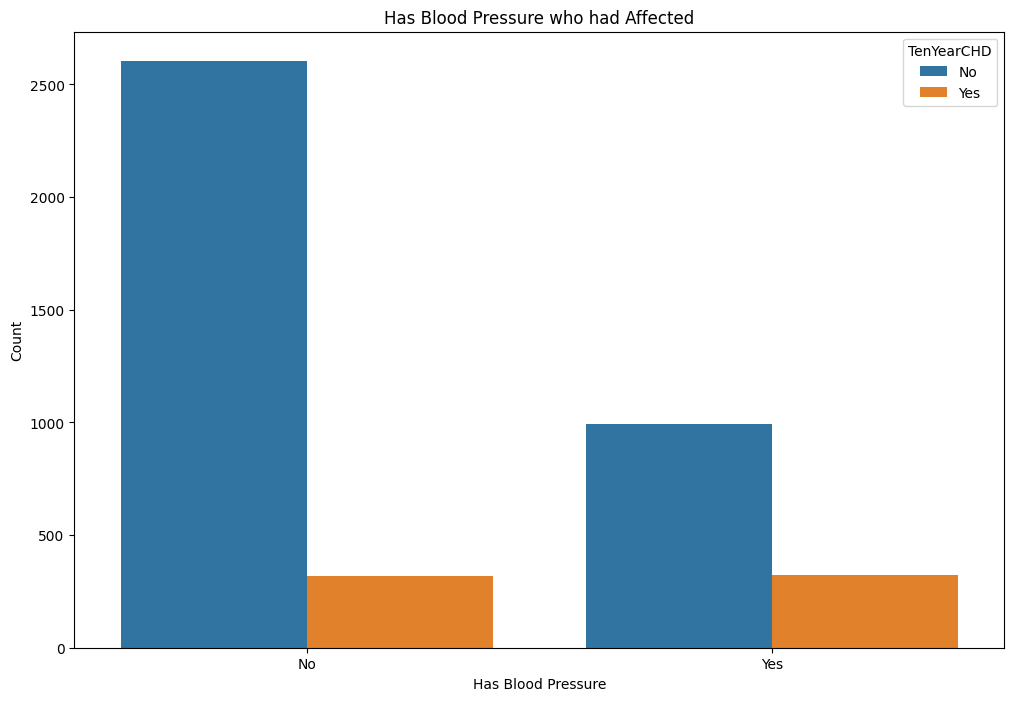

In [52]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='prevalentHyp', hue='TenYearCHD')
plt.xlabel("Has Blood Pressure")
plt.ylabel("Count")
plt.title("Has Blood Pressure who had Affected")
plt.show()

**Has Stroke vs Affected**

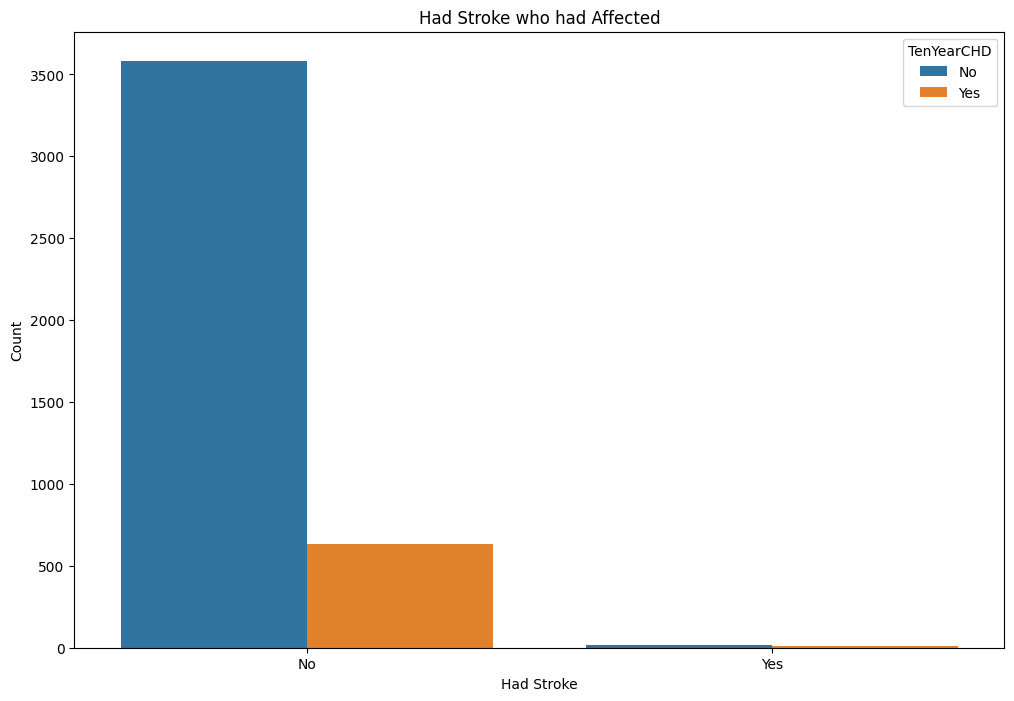

In [53]:
plt.figure(figsize=(12, 8))
sns.countplot(df, x='prevalentStroke', hue='TenYearCHD')
plt.xlabel("Had Stroke")
plt.ylabel("Count")
plt.title("Had Stroke who had Affected")
plt.show()

In [54]:
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [56]:
df = data.copy()

**Basic Info**

In [57]:
print("Shape:", data.shape)
print("\nMissing values:\n", data.isnull().sum())
print("\nClass distribution:\n", data['TenYearCHD'].value_counts())

Shape: (4240, 16)

Missing values:
 male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

Class distribution:
 TenYearCHD
0    3596
1     644
Name: count, dtype: int64


**Feature Engineering**

In [58]:
# Pulse Pressure
df['pulsePressure'] = df['sysBP'] - df['diaBP']

# BMI Category [0=Underweight, 1=Normal, 2=Overweight, 3=Obese]
df['BMI_category'] = pd.cut(df['BMI'],
                            bins=[0,18.5,24.9,29.9,100],
                            labels=[0,1,2,3])

df['BMI_category'] = df['BMI_category'].astype(float)

In [59]:
X = df.drop('TenYearCHD', axis=1)
y = df['TenYearCHD']

In [60]:
binary_cols = [
    'male', 'currentSmoker', 'BPMeds',
    'prevalentStroke', 'prevalentHyp',
    'diabetes'
]

numeric_cols = [
    'age', 'cigsPerDay', 'totChol',
    'sysBP', 'diaBP', 'BMI',
    'heartRate', 'glucose',
    'pulsePressure'
]

categorical_cols = ['education', 'BMI_category']

In [61]:
# Numeric Pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Binary Pipeline (imputing)
binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

# Categorical Pipeline (imputing)
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('bin', binary_pipeline, binary_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ]
)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [64]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (3392, 17)
Testing shape: (848, 17)


In [65]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [66]:
print("Processed training shape:", X_train_processed.shape)

Processed training shape: (3392, 17)


In [67]:
X_train_processed[:5]

array([[-0.42744244,  0.75859082,  1.21332525, -0.06535035,  0.09383158,
        -1.83325679, -0.07422331, -0.59194748, -0.17422129,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         2.        ,  0.        ],
       [ 1.55582444, -0.7517141 ,  0.30327262, -0.67807008, -0.6629691 ,
         0.01347771, -0.07422331,  0.40999157, -0.4809826 ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  2.        ],
       [ 0.97251065, -0.7517141 , -0.37926685,  0.47928941,  1.77561087,
         0.9781535 , -0.07422331,  0.2357413 , -0.71957473,  1.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  2.        ],
       [-0.66076796,  2.60451906, -1.78984842,  0.81968927,  0.34609848,
        -1.06540402, -0.07422331,  0.71492954,  0.95057017,  1.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        